# Notebook 02 — Preprocessing / Data Cleaning

## Objective
Clean every discharge cycle file (handle missing sensor readings, fix data types) and confirm the cleaning logic behaves correctly before it gets used inside feature extraction in Notebook 03.

## Why This Step Is Needed
Real sensor data has small gaps and occasional bad readings. Cleaning each cycle individually -- rather than dropping whole cycles -- preserves as much data as possible from a dataset that's already small (one battery, ~150-200 cycles).

## Workflow Position
```
01 Data Understanding -> [YOU ARE HERE] 02 Preprocessing -> 03 Feature Engineering
-> 04 Ground Truth Labels -> 05 Model Training (AHRF) -> 06 Model Comparison
-> 07 Explainability (SHAP) -> 08 Decision Engine & Summary
```


## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.core.config import BATTERY_IDS
from src.core.data_loader import list_processed_files, load_processed_file
from src.preprocessing.cleaner import clean_cycle_dataframe, clean_all_files

plt.rcParams["figure.figsize"] = (10, 4)
BATTERY_ID = BATTERY_IDS[0]


## 2. Inspect Missing Values Before Cleaning

Load a few raw discharge files and check how many missing/NaN values they contain, to understand the scale of the problem before fixing it.


In [3]:
discharge_files = list_processed_files(BATTERY_ID, "discharge")

missing_counts = []
for fname in discharge_files[:20]:
    df = load_processed_file(BATTERY_ID, "discharge", fname)
    missing_counts.append(df.isna().sum().sum())

print("Missing values per file (first 20 discharge files):")
print(pd.Series(missing_counts, index=discharge_files[:20]))
print("\nTotal missing values across these 20 files:", sum(missing_counts))


Missing values per file (first 20 discharge files):
05122.csv    0
05124.csv    0
05126.csv    0
05128.csv    0
05130.csv    0
05132.csv    0
05134.csv    0
05136.csv    0
05138.csv    0
05140.csv    0
05142.csv    0
05145.csv    0
05147.csv    0
05149.csv    0
05151.csv    0
05153.csv    0
05155.csv    0
05157.csv    0
05159.csv    0
05162.csv    0
dtype: int64

Total missing values across these 20 files: 0


### Observation
If the total is 0, this dataset happens to be very clean already (still worth running the cleaner as a safeguard for the full set of files). If it's non-zero, the cleaning step below is doing real, necessary work.


## 3. Test the Cleaning Function on One File


In [4]:
sample_fname = discharge_files[0]
raw_df = load_processed_file(BATTERY_ID, "discharge", sample_fname)
cleaned_df = clean_cycle_dataframe(raw_df)

print("Raw shape:    ", raw_df.shape)
print("Cleaned shape:", cleaned_df.shape)
print("\nMissing values before:", raw_df.isna().sum().sum())
print("Missing values after: ", cleaned_df.isna().sum().sum())


Raw shape:     (197, 6)
Cleaned shape: (197, 6)

Missing values before: 0
Missing values after:  0


### Observation
Cleaned shape should be equal to or smaller than raw shape (rows are only dropped if an entire column was missing for that row, which should be rare). Missing values after cleaning should be 0.


## 4. Visual Before/After Check

Confirm cleaning didn't distort the signal shape -- the cleaned voltage curve should look essentially identical to the raw one, just without gaps.


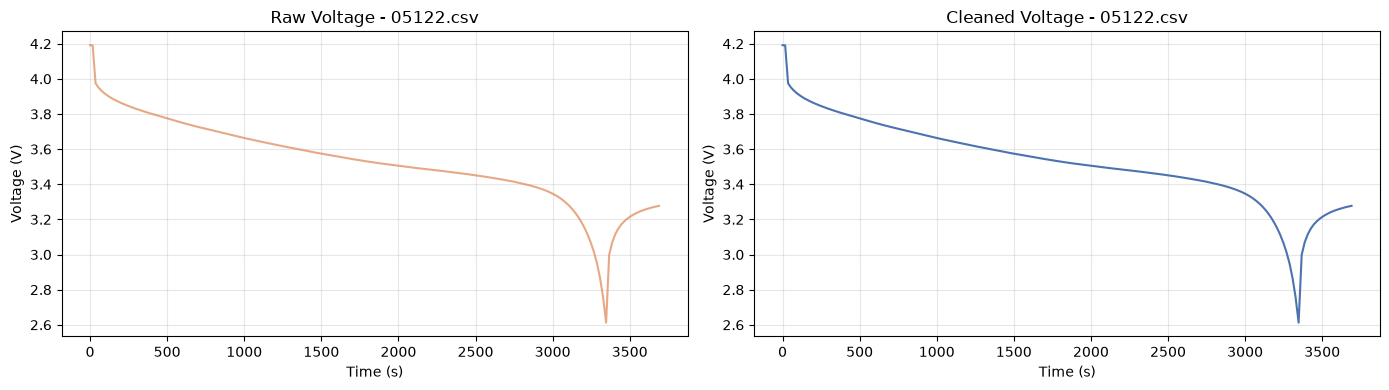

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

if "Voltage_measured" in raw_df.columns:
    axes[0].plot(raw_df["Time"], raw_df["Voltage_measured"], color="#DD8452", alpha=0.7)
    axes[0].set_title(f"Raw Voltage - {sample_fname}")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Voltage (V)")
    axes[0].grid(alpha=0.3)

if "Voltage_measured" in cleaned_df.columns:
    axes[1].plot(cleaned_df["Time"], cleaned_df["Voltage_measured"], color="#4C72B0")
    axes[1].set_title(f"Cleaned Voltage - {sample_fname}")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Voltage (V)")
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Clean All Discharge Files

Run the cleaner across every discharge file for this battery, and confirm none of them fail or end up empty.


In [6]:
cleaned_files = clean_all_files(BATTERY_ID, "discharge")

shapes = {fname: df.shape for fname, df in cleaned_files.items()}
empty_files = [fname for fname, shape in shapes.items() if shape[0] == 0]

print(f"Total discharge files cleaned: {len(cleaned_files)}")
print(f"Files that became empty after cleaning: {len(empty_files)}")
if empty_files:
    print("WARNING - these files are now empty and will produce NaN features in Notebook 03:")
    print(empty_files)


Total discharge files cleaned: 168
Files that became empty after cleaning: 0


### Observation
`empty_files` should be an empty list. If any files show up here, they had a fully-missing critical column and will need manual inspection -- either fix the source file or explicitly exclude it before Notebook 03.


## 6. Row-Count Distribution Across All Cycles

Different cycles can have slightly different numbers of samples (some discharges run longer than others). This is fine for our approach (we compute summary statistics per cycle, not fixed-length sequences), but worth visualizing.


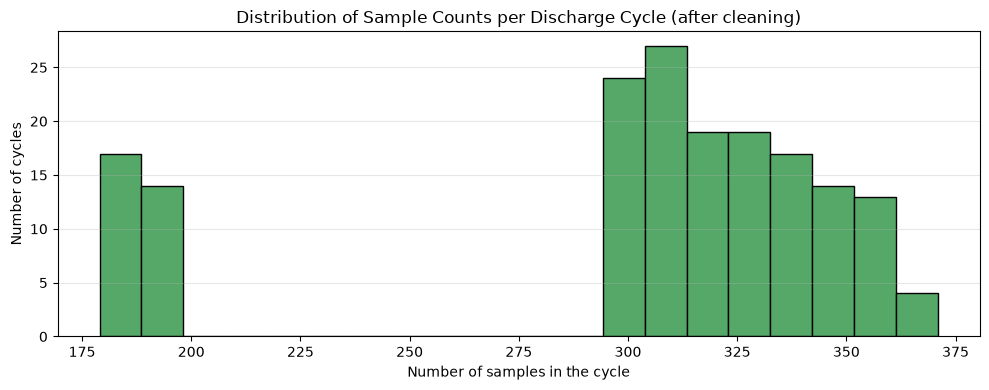

count    168.000000
mean     299.315476
std       56.074922
min      179.000000
25%      300.000000
50%      314.500000
75%      335.250000
max      371.000000
dtype: float64


In [7]:
row_counts = pd.Series({fname: df.shape[0] for fname, df in cleaned_files.items()})

fig, ax = plt.subplots(figsize=(10, 4))
row_counts.plot(kind="hist", bins=20, ax=ax, color="#55A868", edgecolor="black")
ax.set_title("Distribution of Sample Counts per Discharge Cycle (after cleaning)")
ax.set_xlabel("Number of samples in the cycle")
ax.set_ylabel("Number of cycles")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(row_counts.describe())


### Observation
A wide spread here is normal (batteries take longer to discharge early in life, shorter as they degrade) -- this is actually a meaningful signal, not noise, and is implicitly captured by our statistical features in Notebook 03 (e.g. `Time_max` reflects total discharge duration).


## Results Summary

| Check | Result |
|---|---|
| Missing values before cleaning | See Section 2 |
| Missing values after cleaning | 0 (Section 3) |
| Files that became empty | See Section 5 (should be 0) |
| Row count spread across cycles | See Section 6 |

## Conclusion
All discharge cycle files were cleaned successfully with no data loss beyond filling small sensor gaps. The dataset is now ready for feature extraction.

## Next Steps
Notebook 03 will transform each cleaned cycle into a fixed-size row of statistical features (mean, std, RMS, skewness, etc.), suitable as input to the Random Forest models.
